| Technology               | Overnight Cost | Unit    | FOM [%/yr] | Lifetime [years] | Efficiency | Source               |
| ------------------------ | -------------- | ------- | ---------- | ---------------- | ---------- | -------------------- |
| Onshore Wind             | 910            | €/kW_el | 3.3        | 30               | –          | Danish Energy Agency |
| Offshore Wind            | 2506           | €/kW_el | 3          | 25               | –          | Danish Energy Agency |
| Solar PV (utility-scale) | 425            | €/kW_el | 3          | 25               | –          | Danish Energy Agency |
| OCGT                     | 560            | €/kW_el | 3.3        | 25               | 0.39       | Danish Energy Agency |
| Coal (supercritical)     | 2133           | $/kW_el | –          | 40               | 0.41       | OECD/IEA             |
| Nuclear (Gen III)        | 4101           | $/kW_el | –          | 60               | 0.33       | OECD/IEA             |


Danish Energy Agency – Technology Data for Electricity Generation (used in many European energy system models).
**OECD Nuclear Energy Agency / International Energy Agency – Projected Costs of Generating Electricity.

In [1]:
import pandas as pd
pd.set_option("future.infer_string", False)   # ← add this line

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pypsa
import warnings
warnings.filterwarnings("ignore")

In [2]:
def annuity(n, r):
    """Annuity factor for asset with lifetime n years and discount rate r."""
    if r > 0:
        return r / (1.0 - 1.0 / (1.0 + r) ** n)
    else:
        return 1.0 / n

In [3]:
print("Loading data...")
df = pd.read_csv("data.csv", parse_dates=["cet_cest_timestamp"])
df = df.set_index("cet_cest_timestamp")
df = df.apply(pd.to_numeric, errors="coerce")
# Filter to 2017
df_2017 = df[df.index.year == 2017].copy()

# Drop rows where load is 0 or NaN (artefacts at midnight boundary)
df_2017 = df_2017[df_2017["load"] > 0].copy()

# Remove duplicate timestamps (caused by DST clock changes in Germany:
# clocks go back 1 h in October, producing a repeated hour in local time)
df_2017 = df_2017[~df_2017.index.duplicated(keep="first")]

# Build a complete hourly index for 2017 and reindex (forward-fill tiny gaps)
hours_2017 = pd.date_range("2017-01-01 00:00", "2017-12-31 23:00", freq="h")
df_2017 = df_2017.reindex(hours_2017).interpolate(method="time")


print(f"  Snapshots: {len(df_2017)} hours")
print(f"  Load range: {df_2017['load'].min():.0f} – {df_2017['load'].max():.0f} MW")

# Capacity-factor profiles (0–1).  Column names follow the data.csv schema.
cf_onshore  = df_2017["Wind_Onshore Profile"].clip(0, 1)
cf_offshore = df_2017["Wind_Offshore Profile"].clip(0, 1)
cf_solar    = df_2017["Solar Profile"].clip(0, 1)

Loading data...
  Snapshots: 8760 hours
  Load range: 33835 – 77549 MW


In [4]:
# ── 3. Cost parameters ────────────────────────────────────────────────────────
r        = 0.07        # discount rate
usd_eur  = 1 / 1.13   # 2017 average ECB rate  → USD → EUR


#DATA FROM DAWID#

# Capital costs  [€/MW] = overnight_cost [€/kW] * 1000 * annuity * (1 + FOM)
cap_onshore  = annuity(30, r) * 910000  * (1 + 0.033)   # DEA
cap_offshore = annuity(25, r) * 2506000 * (1 + 0.030)  # DEA
cap_solar    = annuity(25, r) * 425000  * (1 + 0.030)   # DEA
cap_ocgt     = annuity(25, r) * 560000  * (1 + 0.033)   # DEA
cap_coal     = annuity(40, r) * 2133000 * usd_eur       # OECD/IEA (no FOM listed → included in fuel/VOM)
cap_nuclear  = annuity(60, r) * 4101000 * usd_eur       # OECD/IEA

# Marginal (fuel) costs  [€/MWh_el] = fuel_cost / efficiency
fuel_gas     = 21.6   # €/MWh_th  (IEA Gas Market Report 2017)
fuel_coal    = 8.5    # €/MWh_th  (IEA Coal 2017 hard-coal import price)
fuel_nuclear = 3.5    # €/MWh_th  (IEA / typical EU nuclear fuel cost)

eff_ocgt    = 0.39
eff_coal    = 0.41
eff_nuclear = 0.33

mc_ocgt    = fuel_gas     / eff_ocgt
mc_coal    = fuel_coal    / eff_coal
mc_nuclear = fuel_nuclear / eff_nuclear

# VOM (variable O&M) additions  [€/MWh_el] — typical values
vom_coal    = 4.0   # €/MWh_el
vom_nuclear = 12.0  # €/MWh_el  (includes decommissioning provision)

mc_coal    += vom_coal
mc_nuclear += vom_nuclear

#DATA FROM 2030#

# Battery storage assumptions from DEA data
battery_max_hours = 2


battery_inverter_investment = 	169.3155 * 1000   # EUR/kW -> 2020 prices: EUR/MW (285.7198)
battery_storage_investment  = 150.2675 * 1000   # EUR/kWh -> 2020 prices EUR/MWh (245.5074)

battery_inverter_fom = 	0.3375 / 100
battery_inverter_lifetime = 10
battery_storage_lifetime = 25.0

battery_inverter_capital_cost = (
    annuity(battery_inverter_lifetime, r)
    * battery_inverter_investment
    * (1 + battery_inverter_fom)
)

battery_storage_capital_cost = battery_storage_investment * (
    annuity(battery_storage_lifetime, r) 
)

battery_efficiency = 0.96   

battery_capital_cost = (
    battery_inverter_capital_cost
    + battery_max_hours * battery_storage_capital_cost
)

print("\nAnnualised capital costs [€/MW/yr]:")
print(f"  Onshore wind : {cap_onshore:,.0f}")
print(f"  Offshore wind: {cap_offshore:,.0f}")
print(f"  Solar PV     : {cap_solar:,.0f}")
print(f"  OCGT         : {cap_ocgt:,.0f}")
print(f"  Coal         : {cap_coal:,.0f}")
print(f"  Nuclear      : {cap_nuclear:,.0f}")
print("\nMarginal costs [€/MWh_el]:")
print(f"  OCGT    : {mc_ocgt:.2f}")
print(f"  Coal    : {mc_coal:.2f}")
print(f"  Nuclear : {mc_nuclear:.2f}")


Annualised capital costs [€/MW/yr]:
  Onshore wind : 75,754
  Offshore wind: 221,492
  Solar PV     : 37,564
  OCGT         : 49,640
  Coal         : 141,588
  Nuclear      : 258,505

Marginal costs [€/MWh_el]:
  OCGT    : 55.38
  Coal    : 24.73
  Nuclear : 22.61


In [5]:
# ── 4. Build PyPSA network ────────────────────────────────────────────────────
print("\nBuilding PyPSA network...")
n = pypsa.Network()
n.set_snapshots(hours_2017)

n.add("Bus", "DE electricity")

# Carriers
n.add("Carrier", "onshorewind")
n.add("Carrier", "offshorewind")
n.add("Carrier", "solar")
n.add("Carrier", "gas",     co2_emissions=0.19)   # tCO2/MWh_th
n.add("Carrier", "coal",    co2_emissions=0.34)   # tCO2/MWh_th
n.add("Carrier", "nuclear", co2_emissions=0.0)
n.add("Carrier", "battery", co2_emissions=0.0)

# Load
n.add("Load", "demand",
      bus="DE electricity",
      p_set=df_2017["load"].values)

# Onshore Wind
n.add("Generator", "Onshore Wind",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="onshorewind",
      capital_cost=cap_onshore,
      marginal_cost=0,
      p_max_pu=cf_onshore.values)

# Offshore Wind
n.add("Generator", "Offshore Wind",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="offshorewind",
      capital_cost=cap_offshore,
      marginal_cost=0,
      p_max_pu=cf_offshore.values)

# Solar PV
n.add("Generator", "Solar PV",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="solar",
      capital_cost=cap_solar,
      marginal_cost=0,
      p_max_pu=cf_solar.values)

# OCGT
n.add("Generator", "OCGT",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="gas",
      capital_cost=cap_ocgt,
      marginal_cost=mc_ocgt,
      efficiency=eff_ocgt)

# Coal
n.add("Generator", "Coal",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="coal",
      capital_cost=cap_coal,
      marginal_cost=mc_coal,
      efficiency=eff_coal)

# Nuclear
n.add("Generator", "Nuclear",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="nuclear",
      capital_cost=cap_nuclear,
      marginal_cost=mc_nuclear,
      efficiency=eff_nuclear)
# Battery storage
n.add(
    "StorageUnit",
    "battery",
    bus="DE electricity",
    carrier="battery",
    max_hours=battery_max_hours,
    capital_cost=battery_capital_cost,
    efficiency_store=battery_efficiency,
    efficiency_dispatch=battery_efficiency,
    p_nom_extendable=True,
    cyclic_state_of_charge=True)



Building PyPSA network...


In [6]:
# ── 5. Optimise ───────────────────────────────────────────────────────────────
print("\nRunning optimisation (Gurobi)...")
n.optimize(solver_name="gurobi")

# ── 6. Results summary ────────────────────────────────────────────────────────
print("\n" + "="*60)
print("OPTIMAL CAPACITIES [GW]")
print("="*60)

for gen, cap in n.generators.p_nom_opt.items():
    print(f"  {gen:<18}: {cap/1000:.2f} GW")

# QUICK BATTERY CHECK
print("\nBattery capacity [GW]:", n.storage_units.p_nom_opt.values/1000)

total_cost = n.objective / 1e9
lcoe = n.objective / n.loads_t.p.sum().values[0]

print(f"\nTotal annualised system cost : {total_cost:.3f} B€/yr")
print(f"System LCOE                  : {lcoe:.2f} €/MWh")

Index(['DE electricity'], dtype='object', name='name')



Running optimisation (Gurobi)...


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 228.90it/s]
INFO:linopy.io: Writing time: 0.44s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

Solved in 25725 iterations and 3.25 seconds (2.29 work units)


INFO:gurobipy:Solved in 25725 iterations and 3.25 seconds (2.29 work units)


Optimal objective  2.203709691e+10


INFO:gurobipy:Optimal objective  2.203709691e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 78847 primals, 175207 duals
Objective: 2.20e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.



OPTIMAL CAPACITIES [GW]
  Onshore Wind      : 21.49 GW
  Offshore Wind     : 0.00 GW
  Solar PV          : 13.12 GW
  OCGT              : 19.30 GW
  Coal              : 54.70 GW
  Nuclear           : 0.00 GW

Battery capacity [GW]: [0.80423494]

Total annualised system cost : 22.037 B€/yr
System LCOE                  : 44.78 €/MWh


In [7]:
# ── 7. Plotting helpers ───────────────────────────────────────────────────────
COLORS = {
    "Onshore Wind" : "#4575b4",
    "Offshore Wind": "#74add1",
    "Solar PV"     : "#fee090",
    "OCGT"         : "#d73027",
    "Coal"         : "#525252",
    "Nuclear"      : "#7b2d8b",
    "demand"       : "black",
}

TECH_ORDER = ["Nuclear", "Coal", "OCGT", "Onshore Wind", "Offshore Wind", "Solar PV"]

def plot_dispatch_week(network, start, title, filename):
    """Stacked area dispatch plot for one week (168 hours)."""
    idx = pd.date_range(start, periods=168, freq="h")
    # Align to network snapshot index
    idx = network.snapshots[
        (network.snapshots >= idx[0]) & (network.snapshots <= idx[-1])
    ]

    fig, ax = plt.subplots(figsize=(14, 5))
    bottom = np.zeros(len(idx))

    for tech in TECH_ORDER:
        if tech in network.generators_t.p.columns:
            gen = network.generators_t.p[tech].loc[idx].values
            ax.fill_between(idx, bottom, bottom + gen,
                            color=COLORS[tech], label=tech, alpha=0.85, step="post")
            bottom += gen

    demand = network.loads_t.p["demand"].loc[idx].values
    ax.step(idx, demand, where="post", color="black",
            linewidth=1.8, label="Demand", linestyle="--")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Power [MW]")
    ax.set_xlabel("")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="upper left", fontsize=9, framealpha=0.8)
    ax.set_xlim(idx[0], idx[-1])
    ax.set_ylim(0)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.savefig(filename, dpi=150)
    print(f"  Saved: {filename}")


Plotting winter dispatch week...


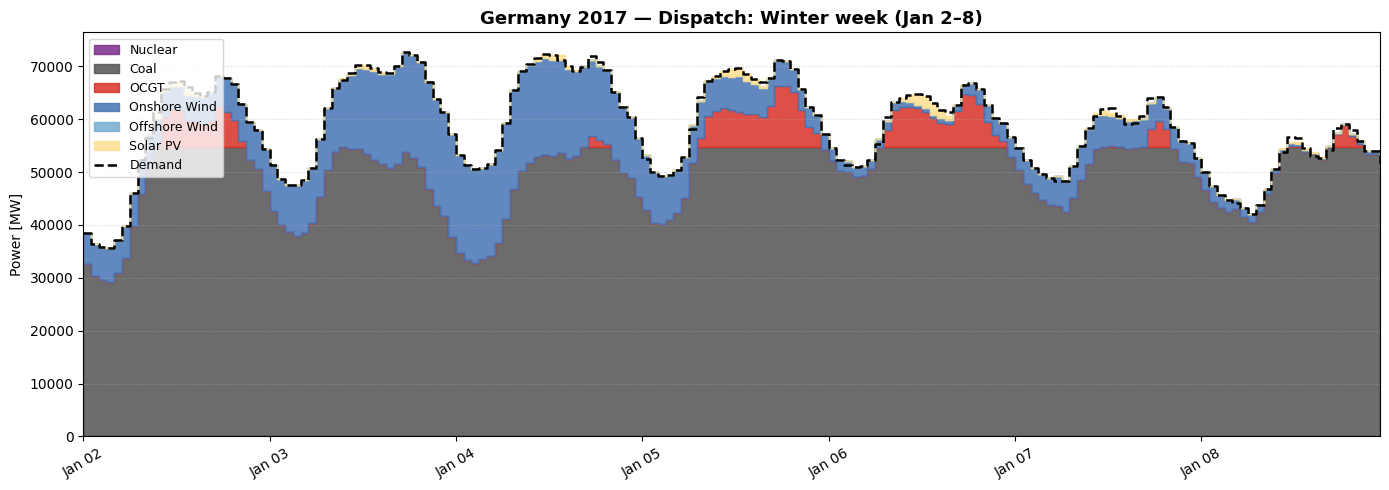

  Saved: dispatch_winter_week.png
Plotting summer dispatch week...


<Figure size 640x480 with 0 Axes>

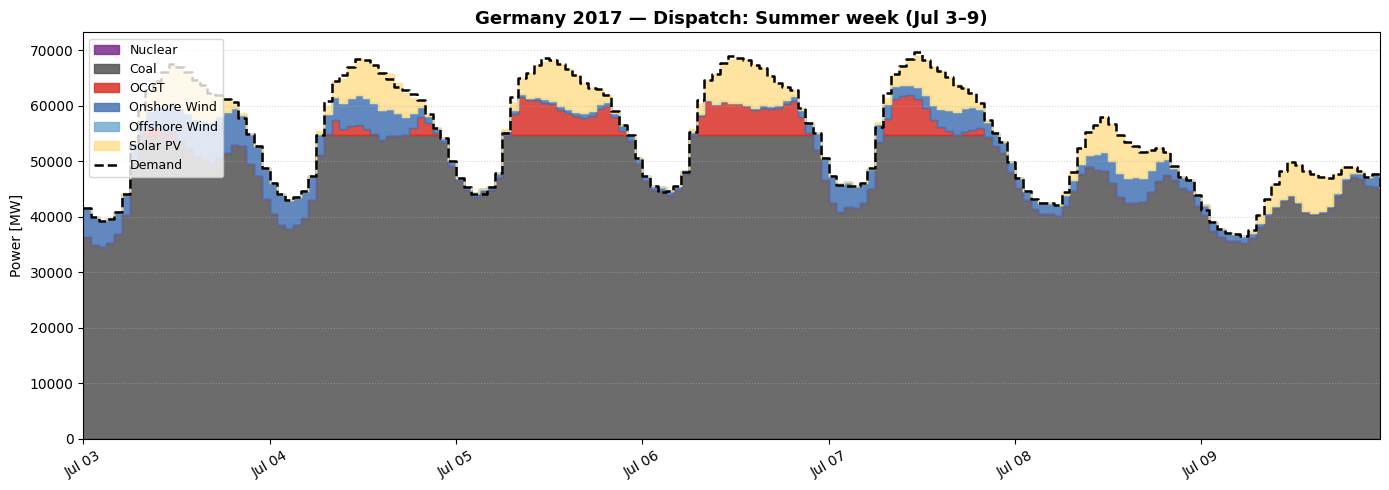

  Saved: dispatch_summer_week.png


<Figure size 640x480 with 0 Axes>

In [8]:
# ── 8. Dispatch: winter week (first full week of January) ─────────────────────
print("\nPlotting winter dispatch week...")
plot_dispatch_week(n,
                   start="2017-01-02",
                   title="Germany 2017 — Dispatch: Winter week (Jan 2–8)",
                   filename="dispatch_winter_week.png")

# ── 9. Dispatch: summer week (first full week of July) ───────────────────────
print("Plotting summer dispatch week...")
plot_dispatch_week(n,
                   start="2017-07-03",
                   title="Germany 2017 — Dispatch: Summer week (Jul 3–9)",
                   filename="dispatch_summer_week.png")

Plotting battery operation for one winter week...


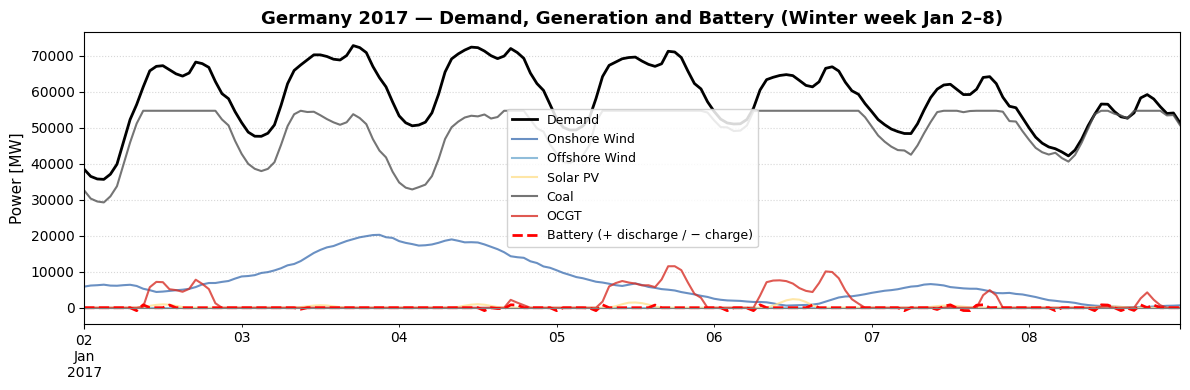

  Saved: dispatch_battery_winter_week.pdf


In [9]:
# ── Battery + full dispatch: winter week ──────────────────────────────────────
print("Plotting battery operation for one winter week...")

week = slice("2017-01-02", "2017-01-08 23:00")

fig, ax = plt.subplots(figsize=(12, 4))

# Demand
n.loads_t.p.loc[week, "demand"].plot(
    ax=ax, label="Demand", color="black", linewidth=2)

# Renewables
n.generators_t.p.loc[week, "Onshore Wind"].plot(
    ax=ax, label="Onshore Wind", color="#4575b4", alpha=0.8)
n.generators_t.p.loc[week, "Offshore Wind"].plot(
    ax=ax, label="Offshore Wind", color="#74add1", alpha=0.8)
n.generators_t.p.loc[week, "Solar PV"].plot(
    ax=ax, label="Solar PV", color="#fee090", alpha=0.8)

# Conventional generators
n.generators_t.p.loc[week, "Coal"].plot(
    ax=ax, label="Coal", color="#525252", alpha=0.8)
n.generators_t.p.loc[week, "OCGT"].plot(
    ax=ax, label="OCGT", color="#d73027", alpha=0.8)

# Battery
n.storage_units_t.p.loc[week, "battery"].plot(
    ax=ax, label="Battery (+ discharge / − charge)",
    color="red", linewidth=2, linestyle="--")

ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Germany 2017 — Demand, Generation and Battery (Winter week Jan 2–8)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Power [MW]", fontsize=11)
ax.set_xlabel("")
ax.legend(fontsize=9, framealpha=0.85)
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("dispatch_battery_winter_week.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("  Saved: dispatch_battery_winter_week.pdf")

Plotting day with strongest battery activity: 2017-01-02


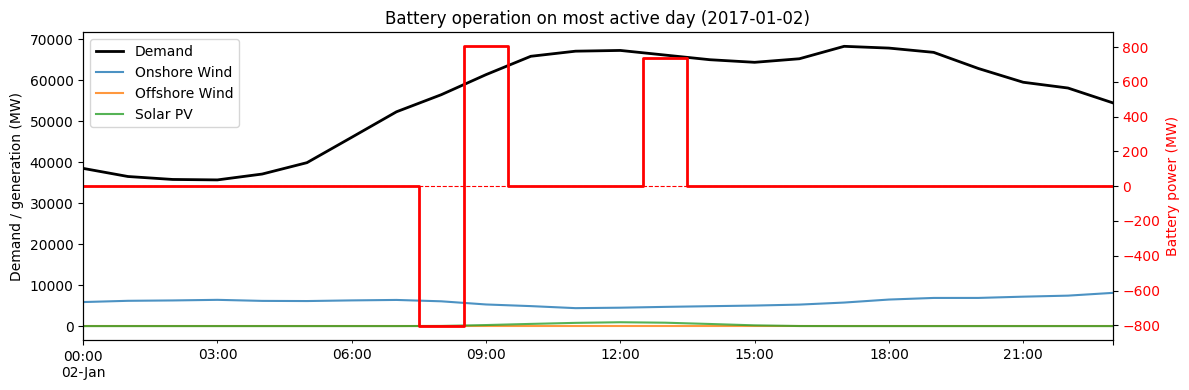

In [10]:
# ── Plot a day with strong battery activity, with battery on secondary axis ──
battery = n.storage_units_t.p["battery"]
active_hour = battery.abs().idxmax()

day_start = active_hour.normalize()
day_end = day_start + pd.Timedelta(hours=23)

print(f"Plotting day with strongest battery activity: {day_start.date()}")

fig, ax1 = plt.subplots(figsize=(12, 4))

# Main axis: demand and renewables
n.loads_t.p.loc[day_start:day_end, "demand"].plot(
    ax=ax1, label="Demand", color="black", linewidth=2
)
n.generators_t.p.loc[day_start:day_end, "Onshore Wind"].plot(
    ax=ax1, label="Onshore Wind", alpha=0.8
)
n.generators_t.p.loc[day_start:day_end, "Offshore Wind"].plot(
    ax=ax1, label="Offshore Wind", alpha=0.8
)
n.generators_t.p.loc[day_start:day_end, "Solar PV"].plot(
    ax=ax1, label="Solar PV", alpha=0.8
)

ax1.set_ylabel("Demand / generation (MW)")
ax1.set_xlabel("")
ax1.legend(loc="upper left")

# Secondary axis: battery
ax2 = ax1.twinx()
battery.loc[day_start:day_end].plot(
    ax=ax2,
    label="Battery",
    color="red",
    linewidth=2,
    drawstyle="steps-mid",
)
ax2.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Battery power (MW)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title(f"Battery operation on most active day ({day_start.date()})")
plt.tight_layout()
plt.show()

Most active summer battery day: 2017-06-01


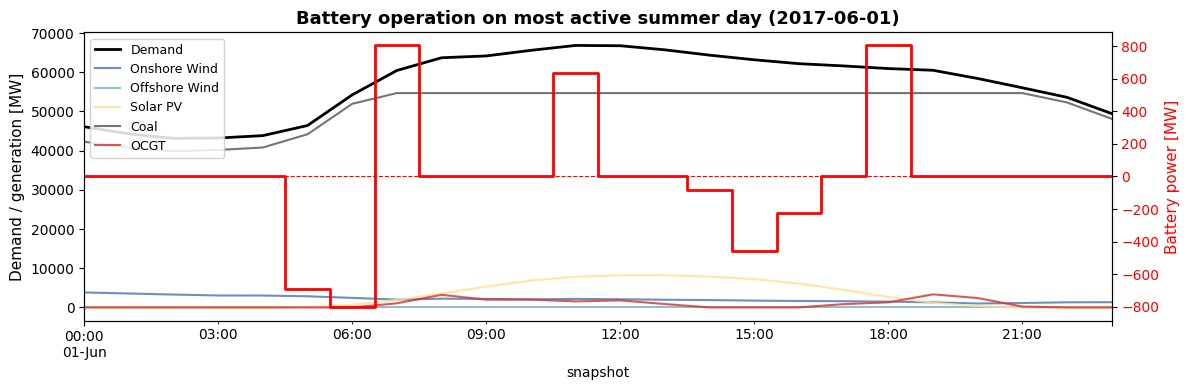

  Saved: battery_summer_day.pdf


In [11]:
# ── Find most active battery day in summer (Jun-Aug) ────────────────────────
battery_summer = n.storage_units_t.p.loc["2017-06-01":"2017-08-31", "battery"]
active_hour = battery_summer.abs().idxmax()

day_start = active_hour.normalize()
day_end = day_start + pd.Timedelta(hours=23)

print(f"Most active summer battery day: {day_start.date()}")

fig, ax1 = plt.subplots(figsize=(12, 4))

# Demand
n.loads_t.p.loc[day_start:day_end, "demand"].plot(
    ax=ax1, label="Demand", color="black", linewidth=2)

# Renewables
n.generators_t.p.loc[day_start:day_end, "Onshore Wind"].plot(
    ax=ax1, label="Onshore Wind", color="#4575b4", alpha=0.8)
n.generators_t.p.loc[day_start:day_end, "Offshore Wind"].plot(
    ax=ax1, label="Offshore Wind", color="#74add1", alpha=0.8)
n.generators_t.p.loc[day_start:day_end, "Solar PV"].plot(
    ax=ax1, label="Solar PV", color="#fee090", alpha=0.8)

# Conventional generators
n.generators_t.p.loc[day_start:day_end, "Coal"].plot(
    ax=ax1, label="Coal", color="#525252", alpha=0.8)
n.generators_t.p.loc[day_start:day_end, "OCGT"].plot(
    ax=ax1, label="OCGT", color="#d73027", alpha=0.8)

ax1.set_ylabel("Demand / generation [MW]", fontsize=11)
ax1.legend(loc="upper left", fontsize=9, framealpha=0.85)

# Battery on secondary axis
ax2 = ax1.twinx()
n.storage_units_t.p.loc[day_start:day_end, "battery"].plot(
    ax=ax2, color="red", linewidth=2, drawstyle="steps-mid",
    label="Battery (+ discharge / − charge)")
ax2.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Battery power [MW]", color="red", fontsize=11)
ax2.tick_params(axis="y", labelcolor="red")

plt.title(f"Battery operation on most active summer day ({day_start.date()})",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("battery_summer_day.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("  Saved: battery_summer_day.pdf")

Plotting battery-price diagnostic for 2017-01-02


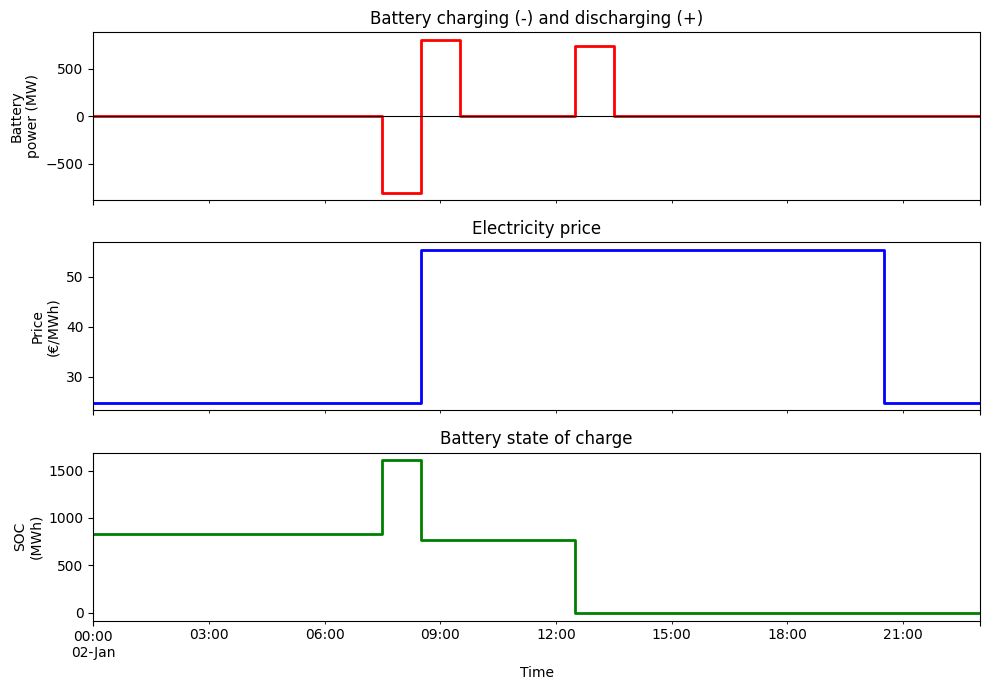

In [12]:
# ── Diagnostic plot: battery vs electricity price ────────────────────────────
battery = n.storage_units_t.p["battery"]
price = n.buses_t.marginal_price["DE electricity"]
soc = n.storage_units_t.state_of_charge["battery"]

# find day with strongest battery activity
active_hour = battery.abs().idxmax()
day_start = active_hour.normalize()
day_end = day_start + pd.Timedelta(hours=23)

print(f"Plotting battery-price diagnostic for {day_start.date()}")

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# 1) Battery charging/discharging
battery.loc[day_start:day_end].plot(
    ax=axes[0], color="red", linewidth=2, drawstyle="steps-mid"
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Battery\npower (MW)")
axes[0].set_title("Battery charging (-) and discharging (+)")

# 2) Electricity price
price.loc[day_start:day_end].plot(
    ax=axes[1], color="blue", linewidth=2, drawstyle="steps-mid"
)
axes[1].set_ylabel("Price\n(€/MWh)")
axes[1].set_title("Electricity price")

# 3) State of charge
soc.loc[day_start:day_end].plot(
    ax=axes[2], color="green", linewidth=2, drawstyle="steps-mid"
)
axes[2].set_ylabel("SOC\n(MWh)")
axes[2].set_title("Battery state of charge")
axes[2].set_xlabel("Time")

plt.tight_layout()
plt.show()

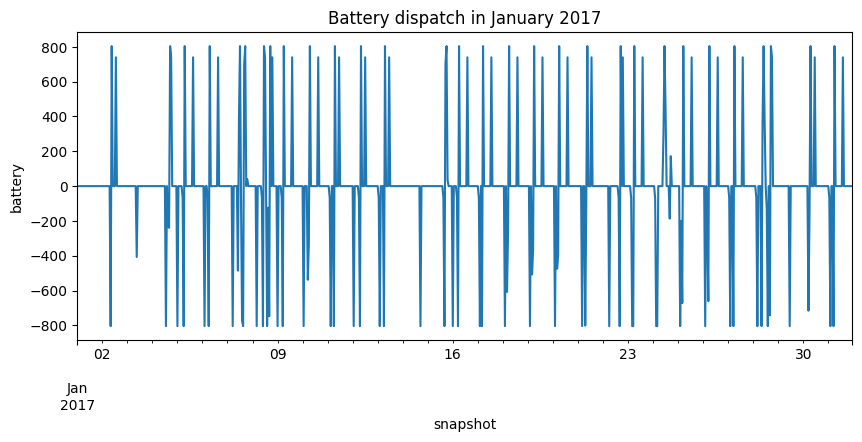

In [13]:
plt.figure(figsize=(10,4))
n.storage_units_t.p["battery"].loc["2017-01"].plot()
plt.ylabel("battery")
plt.xlabel("snapshot")
plt.title("Battery dispatch in January 2017")
plt.show()

Plotting battery behaviour on 2017-01-02


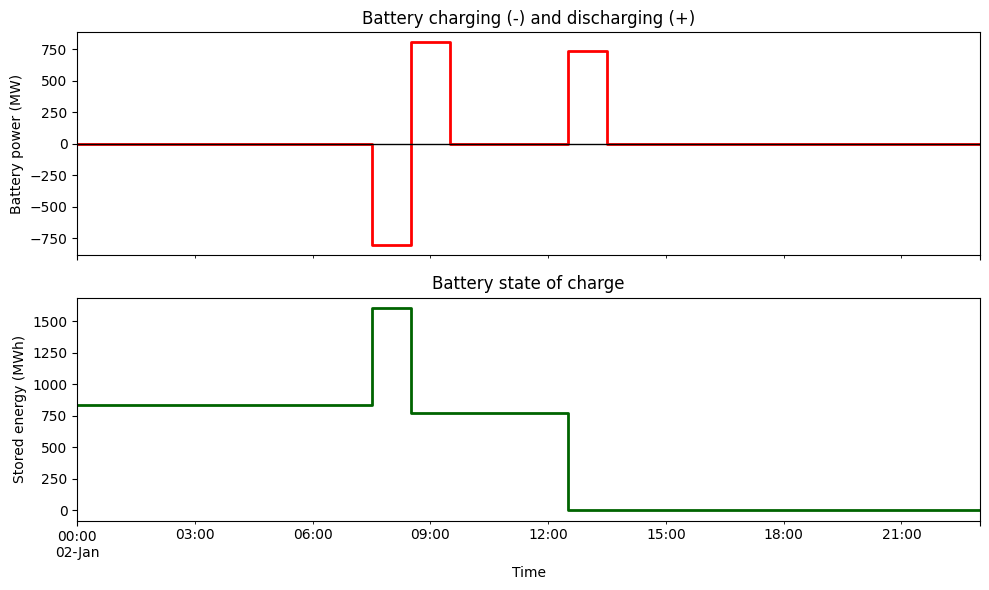

In [14]:
# ── Clean battery operation plot (1 day) ─────────────────────────────────────
battery = n.storage_units_t.p["battery"]
soc = n.storage_units_t.state_of_charge["battery"]

# find day with strongest activity
active_hour = battery.abs().idxmax()
day_start = active_hour.normalize()
day_end = day_start + pd.Timedelta(hours=23)

print(f"Plotting battery behaviour on {day_start.date()}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,6), sharex=True)

# Charging / discharging
battery.loc[day_start:day_end].plot(
    ax=ax1,
    color="red",
    linewidth=2,
    drawstyle="steps-mid"
)
ax1.axhline(0, color="black", linewidth=1)
ax1.set_ylabel("Battery power (MW)")
ax1.set_title("Battery charging (-) and discharging (+)")

# State of charge
soc.loc[day_start:day_end].plot(
    ax=ax2,
    color="darkgreen",
    linewidth=2,
    drawstyle="steps-mid"
)
ax2.set_ylabel("Stored energy (MWh)")
ax2.set_title("Battery state of charge")

plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [15]:
# ── 13. Summary table ─────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Technology':<18} {'Cap [GW]':>10} {'Gen [TWh]':>11} {'CF [%]':>8} {'MC [€/MWh]':>12}")
print("-"*70)
for tech in TECH_ORDER:
    if tech in n.generators_t.p.columns:
        cap = n.generators.loc[tech, "p_nom_opt"] / 1000  # GW
        gen = n.generators_t.p[tech].sum() / 1e6           # TWh
        cf  = (gen * 1e6) / (cap * 1e3 * 8760) if cap > 0 else 0
        mc  = n.generators.loc[tech, "marginal_cost"]
        print(f"  {tech:<16} {cap:>10.2f} {gen:>11.1f} {cf*100:>7.1f}% {mc:>11.2f}")
print("="*70)
print(f"\n  Total annual demand  : {n.loads_t.p['demand'].sum()/1e6:.1f} TWh")
print(f"  System LCOE          : {lcoe:.1f} €/MWh")
print(f"  Total system cost    : {total_cost:.2f} B€/yr")
print("\nAll plots saved. Done!")


Technology           Cap [GW]   Gen [TWh]   CF [%]   MC [€/MWh]
----------------------------------------------------------------------
  Nuclear                0.00         0.0     0.0%       22.61
  Coal                  54.70       414.1    86.4%       24.73
  OCGT                  19.30        16.8    10.0%       55.38
  Onshore Wind          21.49        49.7    26.4%        0.00
  Offshore Wind          0.00         0.0     0.0%        0.00
  Solar PV              13.12        11.5    10.0%        0.00

  Total annual demand  : 492.1 TWh
  System LCOE          : 44.8 €/MWh
  Total system cost    : 22.04 B€/yr

All plots saved. Done!


Note, Part F takes a while before being computed!! 

In [ ]:
# ── Task F: CO2 constraint sensitivity ───────────────────────────────────────
#
# Reference: 8-year average (2018-2025) of German electricity sector CO2
# Source: Nowtricity (ENTSO-E data) — https://www.nowtricity.com/country/germany/
#
# Year  | Intensity (gCO2/kWh) | Generation (TWh) | CO2 (Mt)
# 2018  |  402                 |  541.6            | 217.7
# 2019  |  348                 |  519.3            | 180.7
# 2020  |  314                 |  492.5            | 154.6
# 2021  |  355                 |  500.5            | 177.7
# 2022  |  380                 |  494.2            | 187.8
# 2023  |  354                 |  442.4            | 156.6
# 2024  |  321                 |  429.1            | 137.7
# 2025  |  328                 |  432.0            | 141.7
# Average: 350 gCO2/kWh | 481.4 TWh | 169.3 Mt CO2
# ─────────────────────────────────────────────────────────────────────────────
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
import warnings
warnings.filterwarnings("ignore")
 
CO2_REF = 169.3   # Mt CO2 — 8-year average 2018-2025, Nowtricity / ENTSO-E
 
# ── 10 runs: unconstrained + 8 evenly spaced 200→10 Mt + forced 5 Mt ─────────
co2_limits_Mt = [None] + list(np.linspace(200, 10, 8)) + [5]
 
TECHS   = ["Onshore Wind", "Offshore Wind", "Solar PV", "OCGT", "Coal", "Nuclear"]
STORAGE = ["Battery"]
ALL     = TECHS + STORAGE
 
# CO2 intensity per technology [tCO2/MWh_el] for reporting
# = carrier_co2 / efficiency (zero for renewables/nuclear/battery)
TECH_CO2 = {
    "Onshore Wind" : 0.0,
    "Offshore Wind": 0.0,
    "Solar PV"     : 0.0,
    "OCGT"         : 0.19 / 0.39,
    "Coal"         : 0.34 / 0.41,
    "Nuclear"      : 0.0,
    "Battery"      : 0.0,
}
 
COLORS = {
    "Onshore Wind" : "#4575b4",
    "Offshore Wind": "#74add1",
    "Solar PV"     : "#fee090",
    "OCGT"         : "#d73027",
    "Coal"         : "#525252",
    "Nuclear"      : "#7b2d8b",
    "Battery"      : "#2ca02c",
}
 
def run_with_co2_limit(co2_limit_Mt):
    net = pypsa.Network()
    net.set_snapshots(hours_2017)
 
    net.add("Bus", "DE electricity")
    net.add("Carrier", "onshorewind")
    net.add("Carrier", "offshorewind")
    net.add("Carrier", "solar")
    net.add("Carrier", "gas",     co2_emissions=0.19)
    net.add("Carrier", "coal",    co2_emissions=0.34)
    net.add("Carrier", "nuclear", co2_emissions=0.0)
    net.add("Carrier", "battery", co2_emissions=0.0)
 
    net.add("Load", "demand", bus="DE electricity", p_set=df_2017["load"].values)
 
    net.add("Generator", "Onshore Wind",  bus="DE electricity", p_nom_extendable=True,
            carrier="onshorewind",  capital_cost=cap_onshore,  marginal_cost=0,
            p_max_pu=cf_onshore.values)
    net.add("Generator", "Offshore Wind", bus="DE electricity", p_nom_extendable=True,
            carrier="offshorewind", capital_cost=cap_offshore, marginal_cost=0,
            p_max_pu=cf_offshore.values)
    net.add("Generator", "Solar PV",      bus="DE electricity", p_nom_extendable=True,
            carrier="solar",        capital_cost=cap_solar,    marginal_cost=0,
            p_max_pu=cf_solar.values)
    net.add("Generator", "OCGT",          bus="DE electricity", p_nom_extendable=True,
            carrier="gas",          capital_cost=cap_ocgt,     marginal_cost=mc_ocgt,
            efficiency=eff_ocgt)
    net.add("Generator", "Coal",          bus="DE electricity", p_nom_extendable=True,
            carrier="coal",         capital_cost=cap_coal,     marginal_cost=mc_coal,
            efficiency=eff_coal)
    net.add("Generator", "Nuclear",       bus="DE electricity", p_nom_extendable=True,
            carrier="nuclear",      capital_cost=cap_nuclear,  marginal_cost=mc_nuclear,
            efficiency=eff_nuclear)
 
    net.add("StorageUnit", "battery",
            bus="DE electricity", carrier="battery",
            p_nom_extendable=True,
            capital_cost=battery_inverter_capital_cost + battery_storage_capital_cost * battery_max_hours,
            max_hours=battery_max_hours,
            efficiency_store=battery_efficiency,
            efficiency_dispatch=battery_efficiency,
            cyclic_state_of_charge=True)
 
    if co2_limit_Mt is not None:
        net.add("GlobalConstraint", "co2_limit",
                sense="<=",
                constant=co2_limit_Mt * 1e6,
                carrier_attribute="co2_emissions")
 
    net.optimize(solver_name="gurobi")
    return net
 
 
# ── Run the sweep ─────────────────────────────────────────────────────────────
print("Running CO2 constraint sweep (10 optimisations)...")
records = []
 
for limit in co2_limits_Mt:
    label = f"{limit:.0f} Mt" if limit is not None else "Unconstrained"
    print(f"  → {label}")
 
    try:
        net = run_with_co2_limit(limit)
 
        # Actual total CO2 [Mt]
        co2_actual = sum(
            net.generators_t.p[gen].sum()
            / net.generators.loc[gen, "efficiency"]
            * net.carriers.loc[net.generators.loc[gen, "carrier"], "co2_emissions"]
            for gen in net.generators.index
            if net.generators.loc[gen, "carrier"] in ["gas", "coal"]
        ) / 1e6
 
        # Per-technology generation [TWh] and emissions [Mt]
        gen_TWh, em_Mt = {}, {}
        for t in TECHS:
            if t in net.generators_t.p.columns:
                g = net.generators_t.p[t].sum() / 1e6
                gen_TWh[t] = g
                em_Mt[t]   = g * TECH_CO2[t]   # TWh * tCO2/MWh_el = Mt CO2
            else:
                gen_TWh[t] = 0.0
                em_Mt[t]   = 0.0
 
        # Battery generation (discharge) [TWh]
        gen_TWh["Battery"] = (
            net.storage_units_t.p["battery"].clip(lower=0).sum() / 1e6
            if "battery" in net.storage_units_t.p.columns else 0.0
        )
        em_Mt["Battery"] = 0.0
 
        # Capacity [GW]
        cap_GW = {t: net.generators.loc[t, "p_nom_opt"] / 1e3
                  for t in TECHS if t in net.generators.index}
        cap_GW["Battery"] = (
            net.storage_units.loc["battery", "p_nom_opt"] / 1e3
            if "battery" in net.storage_units.index else 0.0
        )
 
        lcoe = net.objective / net.loads_t.p.sum().values[0]
 
        records.append({
            "scenario"  : label,
            "limit_Mt"  : limit if limit is not None else np.nan,
            "co2_actual": co2_actual,
            "lcoe"      : lcoe,
            **{f"cap_{t}": cap_GW.get(t, 0)  for t in ALL},
            **{f"gen_{t}": gen_TWh.get(t, 0) for t in ALL},
            **{f"em_{t}" : em_Mt.get(t, 0)   for t in ALL},
        })
 
    except Exception as e:
        print(f"    ✗ Failed: {e}")
 
results_df = pd.DataFrame(records).sort_values("co2_actual", ascending=False).reset_index(drop=True)
print(f"\nSweep complete — {len(results_df)} successful runs.")

Running CO2 constraint sweep (10 optimisations)...
  → Unconstrained


Index(['DE electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 239.36it/s]
INFO:linopy.io: Writing time: 0.35s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2775732


...

INFO:gurobipy:  73   2.31481900e+10  2.31469003e+10  1.37e-02 5.76e-08  8.61e+00     5s


  74   2.31480921e+10  2.31470403e+10  9.56e-03 3.54e-08  7.02e+00     5s


INFO:gurobipy:  74   2.31480921e+10  2.31470403e+10  9.56e-03 3.54e-08  7.02e+00     5s


  75   2.31479739e+10  2.31473027e+10  4.42e-03 4.31e-08  4.48e+00     5s


INFO:gurobipy:  75   2.31479739e+10  2.31473027e+10  4.42e-03 4.31e-08  4.48e+00     5s


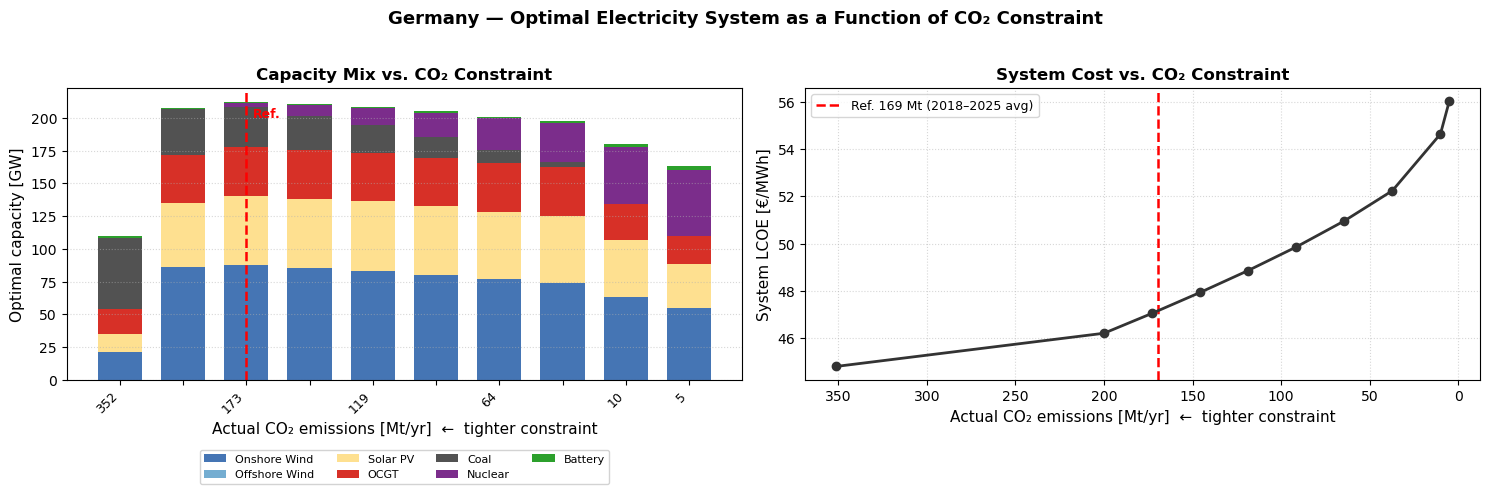

  Saved: taskF_co2_sweep.pdf

SUMMARY TABLE — CO2 CONSTRAINT SWEEP
Scenario            CO2 [Mt]     LCOE Cap Onshore Wind Cap Offshore Wind Cap Solar PV    Cap OCGT    Cap Coal Cap Nuclear Cap Battery Gen Onshore Wind Gen Offshore Wind Gen Solar PV    Gen OCGT    Gen Coal Gen Nuclear Gen Battery    Em OCGT    Em Coal
--------------------------------------------------------------------------------------------------------------
Unconstrained          351.6    44.78       21.49        0.00       13.12       19.30       54.70        0.00        0.80        49.7         0.0        11.5        16.8       414.1         0.0         0.4       8.21     343.36
200 Mt                 200.0    46.19       86.42        0.00       48.57       36.67       35.04        0.00        0.62       192.3         0.0        42.7        38.7       218.4         0.0         0.4      18.88     181.12
173 Mt                 172.9    47.04       87.53        0.00       52.48       37.44       30.61        3.45     

In [ ]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
 
x      = results_df["co2_actual"].values
n_bars = len(x)
 
# ── Panel 1: Capacity mix ─────────────────────────────────────────────────────
bottom = np.zeros(n_bars)
for tech in ALL:
    col = f"cap_{tech}"
    if col in results_df.columns:
        vals = results_df[col].values
        ax1.bar(range(n_bars), vals, bottom=bottom,
                color=COLORS[tech], label=tech, width=0.7)
        bottom += vals
 
ref_idx = int(np.argmin(np.abs(x - CO2_REF)))
ax1.axvline(ref_idx, color="red", linestyle="--", linewidth=1.8)
ax1.text(ref_idx + 0.1, bottom.max() * 0.98,
         "Ref.", color="red", fontsize=9, va="top", fontweight="bold")
 
# x-axis: every other label shown; last bar explicitly "0"
tick_labels = []
for i, v in enumerate(x):
    if i == n_bars - 1:
        tick_labels.append("5")
    elif i % 2 == 0:
        tick_labels.append(f"{v:.0f}")
    else:
        tick_labels.append("")
 
ax1.set_xticks(range(n_bars))
ax1.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
ax1.set_xlabel("Actual CO₂ emissions [Mt/yr]  ←  tighter constraint", fontsize=11)
ax1.set_ylabel("Optimal capacity [GW]", fontsize=11)
ax1.set_title("Capacity Mix vs. CO₂ Constraint", fontsize=12, fontweight="bold")
ax1.legend(fontsize=8, loc="upper center",
           bbox_to_anchor=(0.5, -0.22), ncol=4, framealpha=0.85)
ax1.grid(axis="y", linestyle=":", alpha=0.5)
 
# ── Panel 2: LCOE ─────────────────────────────────────────────────────────────
ax2.plot(x, results_df["lcoe"].values, color="#333333",
         linewidth=2, marker="o", markersize=6, zorder=3)
ax2.axvline(CO2_REF, color="red", linestyle="--", linewidth=1.8,
            label=f"Ref. {CO2_REF:.0f} Mt (2018–2025 avg)")
ax2.invert_xaxis()
ax2.set_xlabel("Actual CO₂ emissions [Mt/yr]  ←  tighter constraint", fontsize=11)
ax2.set_ylabel("System LCOE [€/MWh]", fontsize=11)
ax2.set_title("System Cost vs. CO₂ Constraint", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(linestyle=":", alpha=0.5)
 
plt.suptitle(
    "Germany — Optimal Electricity System as a Function of CO₂ Constraint",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("taskF_co2_sweep.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("  Saved: taskF_co2_sweep.pdf")
 
 
# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*110)
print("SUMMARY TABLE — CO2 CONSTRAINT SWEEP")
print("="*110)
 
# Header
hdr  = f"{'Scenario':<18} {'CO2 [Mt]':>9} {'LCOE':>8}"
hdr += "".join(f" {'Cap '+t:>11}" for t in ALL)
hdr += "".join(f" {'Gen '+t:>11}" for t in ALL)
hdr += "".join(f" {'Em '+t:>10}"  for t in ["OCGT", "Coal"])
print(hdr)
print("-"*110)
 
for _, row in results_df.iterrows():
    line  = f"{row['scenario']:<18} {row['co2_actual']:>9.1f} {row['lcoe']:>8.2f}"
    line += "".join(f" {row[f'cap_{t}']:>11.2f}" for t in ALL)
    line += "".join(f" {row[f'gen_{t}']:>11.1f}" for t in ALL)
    line += "".join(f" {row[f'em_{t}']:>10.2f}"  for t in ["OCGT", "Coal"])
    print(line)
 
print("="*110)
print("Units: CO2 [Mt/yr] | LCOE [€/MWh] | Capacity [GW] | Generation [TWh] | Emissions [Mt CO2]")
 

In [ ]:
TECHS  = ["Onshore Wind", "Offshore Wind", "Solar PV", "OCGT", "Coal", "Nuclear"]
ALL    = TECHS + ["Battery"]
COLORS = {
    "Onshore Wind" : "#4575b4",
    "Offshore Wind": "#74add1",
    "Solar PV"     : "#fee090",
    "OCGT"         : "#d73027",
    "Coal"         : "#525252",
    "Nuclear"      : "#7b2d8b",
    "Battery"      : "#2ca02c",
}

Running gas price sweep (4 optimisations, ETS = 75 €/tCO₂, no CO₂ cap)...
  → Pre-crisis (21.6 €/MWh)


Index(['DE electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 125.02it/s]
INFO:linopy.io: Writing time: 1.09s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2774416


...

Solved in 16971 iterations and 20.90 seconds (2.80 work units)


INFO:gurobipy:Solved in 16971 iterations and 20.90 seconds (2.80 work units)


Optimal objective  2.932987396e+10


INFO:gurobipy:Optimal objective  2.932987396e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 78847 primals, 175207 duals
Objective: 2.93e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.



Sweep complete — 4 successful runs.


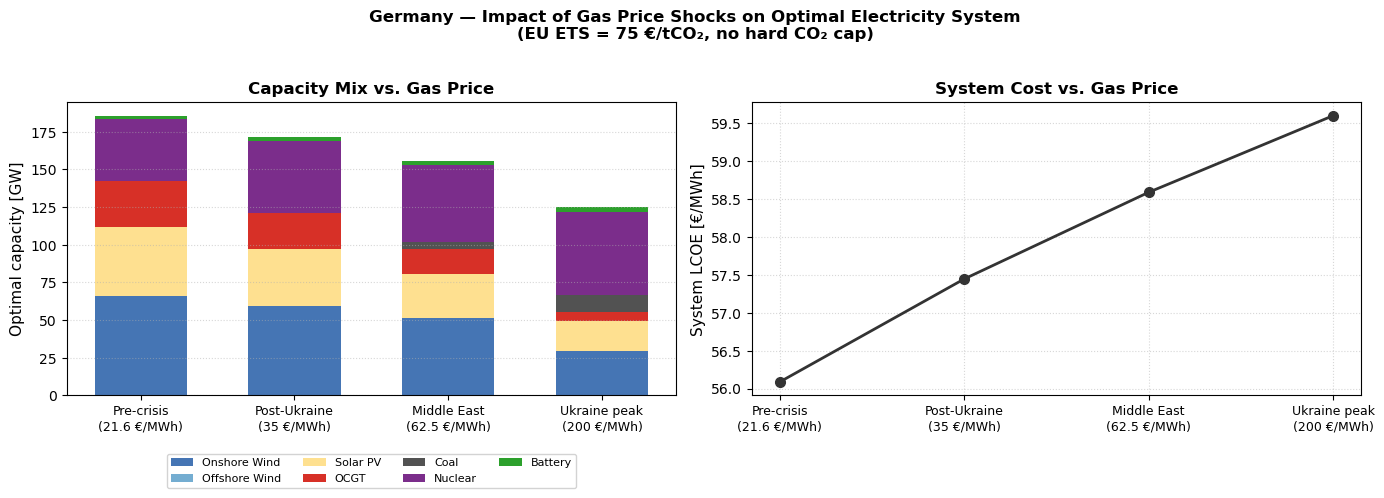

  Saved: taskJ_gas_sweep.pdf

TASK J — GAS PRICE SENSITIVITY SUMMARY (EU ETS = 75 €/tCO₂, no CO₂ cap)

Scenario                       Gas      CO₂     LCOE     Wind    Solar     OCGT     Coal  Nuclear  Battery
                          €/MWh_th    Mt/yr    €/MWh       GW       GW       GW       GW       GW       GW
-----------------------------------------------------------------------------------------------
Pre-crisis (21.6 €/MWh)       21.6     13.3    56.09     66.2     45.5     30.5      0.0     41.0      2.1
Post-Ukraine (35 €/MWh)       35.0      6.8    57.45     59.1     38.1     24.1      0.0     47.6      2.4
Middle East (62.5 €/MWh)      62.5      7.5    58.59     51.5     29.2     16.3      5.0     50.8      2.9
Ukraine peak (200 €/MWh)     200.0      7.7    59.60     29.1     20.0      5.9     11.5     55.3      2.9

Change vs. pre-crisis baseline [GW / €/MWh]:
Scenario                     ΔOCGT    ΔCoal    ΔWind   ΔSolar ΔNuclear     ΔCO₂    ΔLCOE
------------------------

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# TASK J — Gas Price Sensitivity with EU ETS at 75 €/tCO₂ (no hard CO₂ cap)
# Assumes the following are already defined from earlier cells:
#   df_2017, cf_onshore, cf_offshore, cf_solar
#   cap_onshore, cap_offshore, cap_solar, cap_ocgt, cap_coal, cap_nuclear
#   mc_coal, mc_nuclear, eff_ocgt, eff_coal, eff_nuclear
#   battery_inverter_capital_cost, battery_storage_capital_cost,
#   battery_max_hours, battery_efficiency
# ═══════════════════════════════════════════════════════════════════════════════

GAS_SCENARIOS = [
    {"label": "Pre-crisis\n(21.6 €/MWh)",  "fuel_gas": 21.6},
    {"label": "Post-Ukraine\n(35 €/MWh)",   "fuel_gas": 35.0},
    {"label": "Middle East\n(62.5 €/MWh)",  "fuel_gas": 62.5},
    {"label": "Ukraine peak\n(200 €/MWh)",  "fuel_gas": 200.0},
]

ETS_PRICE = 75.0  # €/tCO₂ — current EU ETS price

TECHS  = ["Onshore Wind", "Offshore Wind", "Solar PV", "OCGT", "Coal", "Nuclear"]
ALL    = TECHS + ["Battery"]
COLORS = {
    "Onshore Wind" : "#4575b4",
    "Offshore Wind": "#74add1",
    "Solar PV"     : "#fee090",
    "OCGT"         : "#d73027",
    "Coal"         : "#525252",
    "Nuclear"      : "#7b2d8b",
    "Battery"      : "#2ca02c",
}
TECH_CO2 = {
    "Onshore Wind" : 0.0,
    "Offshore Wind": 0.0,
    "Solar PV"     : 0.0,
    "OCGT"         : 0.19 / 0.39,
    "Coal"         : 0.34 / 0.41,
    "Nuclear"      : 0.0,
    "Battery"      : 0.0,
}


def run_with_gas_price(fuel_gas_price):
    """Build and optimise the single-country DE model with a given gas fuel
    price and EU ETS carbon price applied to both gas and coal. No hard CO₂ cap."""

    ets_adder_ocgt = (0.19 / eff_ocgt) * ETS_PRICE   # ≈ 36.5 €/MWh_el
    ets_adder_coal = (0.34 / eff_coal) * ETS_PRICE    # ≈ 62.2 €/MWh_el

    mc_ocgt_local = fuel_gas_price / eff_ocgt + ets_adder_ocgt
    mc_coal_local = mc_coal + ets_adder_coal

    net = pypsa.Network()
    net.set_snapshots(hours_2017)

    net.add("Bus", "DE electricity")
    net.add("Carrier", "onshorewind")
    net.add("Carrier", "offshorewind")
    net.add("Carrier", "solar")
    net.add("Carrier", "gas",     co2_emissions=0.19)
    net.add("Carrier", "coal",    co2_emissions=0.34)
    net.add("Carrier", "nuclear", co2_emissions=0.0)
    net.add("Carrier", "battery", co2_emissions=0.0)

    net.add("Load", "demand", bus="DE electricity", p_set=df_2017["load"].values)

    net.add("Generator", "Onshore Wind",  bus="DE electricity", p_nom_extendable=True,
            carrier="onshorewind",  capital_cost=cap_onshore,  marginal_cost=0,
            p_max_pu=cf_onshore.values)
    net.add("Generator", "Offshore Wind", bus="DE electricity", p_nom_extendable=True,
            carrier="offshorewind", capital_cost=cap_offshore, marginal_cost=0,
            p_max_pu=cf_offshore.values)
    net.add("Generator", "Solar PV",      bus="DE electricity", p_nom_extendable=True,
            carrier="solar",        capital_cost=cap_solar,    marginal_cost=0,
            p_max_pu=cf_solar.values)
    net.add("Generator", "OCGT",          bus="DE electricity", p_nom_extendable=True,
            carrier="gas",          capital_cost=cap_ocgt,     marginal_cost=mc_ocgt_local,
            efficiency=eff_ocgt)
    net.add("Generator", "Coal",          bus="DE electricity", p_nom_extendable=True,
            carrier="coal",         capital_cost=cap_coal,     marginal_cost=mc_coal_local,
            efficiency=eff_coal)
    net.add("Generator", "Nuclear",       bus="DE electricity", p_nom_extendable=True,
            carrier="nuclear",      capital_cost=cap_nuclear,  marginal_cost=mc_nuclear,
            efficiency=eff_nuclear)
    net.add("StorageUnit", "battery",
            bus="DE electricity", carrier="battery",
            p_nom_extendable=True,
            capital_cost=battery_inverter_capital_cost + battery_storage_capital_cost * battery_max_hours,
            max_hours=battery_max_hours,
            efficiency_store=battery_efficiency,
            efficiency_dispatch=battery_efficiency,
            cyclic_state_of_charge=True)

    # No GlobalConstraint — ETS price signal only
    net.optimize(solver_name="gurobi")
    return net


# ── Run the sweep ──────────────────────────────────────────────────────────────
print("Running gas price sweep (4 optimisations, ETS = 75 €/tCO₂, no CO₂ cap)...")
gas_records = []

for scenario in GAS_SCENARIOS:
    label     = scenario["label"]
    gas_price = scenario["fuel_gas"]
    print(f"  → {label.replace(chr(10), ' ')}")

    try:
        net = run_with_gas_price(gas_price)

        # Actual CO2 [Mt]
        co2_actual = sum(
            net.generators_t.p[gen].sum()
            / net.generators.loc[gen, "efficiency"]
            * net.carriers.loc[net.generators.loc[gen, "carrier"], "co2_emissions"]
            for gen in net.generators.index
            if net.generators.loc[gen, "carrier"] in ["gas", "coal"]
        ) / 1e6

        # Capacity [GW]
        cap_GW = {t: net.generators.loc[t, "p_nom_opt"] / 1e3
                  for t in TECHS if t in net.generators.index}
        cap_GW["Battery"] = (
            net.storage_units.loc["battery", "p_nom_opt"] / 1e3
            if "battery" in net.storage_units.index else 0.0
        )

        # Generation [TWh]
        gen_TWh = {}
        for t in TECHS:
            gen_TWh[t] = (net.generators_t.p[t].sum() / 1e6
                          if t in net.generators_t.p.columns else 0.0)
        gen_TWh["Battery"] = (
            net.storage_units_t.p["battery"].clip(lower=0).sum() / 1e6
            if "battery" in net.storage_units_t.p.columns else 0.0
        )

        lcoe = net.objective / net.loads_t.p.sum().values[0]

        gas_records.append({
            "label"     : label,
            "fuel_gas"  : gas_price,
            "co2_actual": co2_actual,
            "lcoe"      : lcoe,
            **{f"cap_{t}": cap_GW.get(t, 0)  for t in ALL},
            **{f"gen_{t}": gen_TWh.get(t, 0) for t in ALL},
        })

    except Exception as e:
        print(f"    ✗ Failed: {e}")

gas_df = pd.DataFrame(gas_records)
print(f"\nSweep complete — {len(gas_df)} successful runs.")


# ── Plot ───────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_bars   = len(gas_df)
x_pos    = np.arange(n_bars)
x_labels = gas_df["label"].values

# Panel 1: Capacity mix (stacked bar)
bottom = np.zeros(n_bars)
for tech in ALL:
    col = f"cap_{tech}"
    if col in gas_df.columns:
        vals = gas_df[col].values
        ax1.bar(x_pos, vals, bottom=bottom,
                color=COLORS[tech], label=tech, width=0.6)
        bottom += vals

ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, fontsize=9)
ax1.set_ylabel("Optimal capacity [GW]", fontsize=11)
ax1.set_title("Capacity Mix vs. Gas Price", fontsize=12, fontweight="bold")
ax1.legend(fontsize=8, loc="upper center",
           bbox_to_anchor=(0.5, -0.18), ncol=4, framealpha=0.85)
ax1.grid(axis="y", linestyle=":", alpha=0.5)

# Panel 2: System LCOE
ax2.plot(x_pos, gas_df["lcoe"].values, color="#333333",
         linewidth=2, marker="o", markersize=7, zorder=3)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels, fontsize=9)
ax2.set_ylabel("System LCOE [€/MWh]", fontsize=11)
ax2.set_title("System Cost vs. Gas Price", fontsize=12, fontweight="bold")
ax2.grid(linestyle=":", alpha=0.5)

plt.suptitle(
    "Germany — Impact of Gas Price Shocks on Optimal Electricity System\n"
    "(EU ETS = 75 €/tCO₂, no hard CO₂ cap)",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("taskJ_gas_sweep.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("  Saved: taskJ_gas_sweep.pdf")


# ── Numerical Results Summary ──────────────────────────────────────────────────
print("\n" + "="*95)
print("TASK J — GAS PRICE SENSITIVITY SUMMARY (EU ETS = 75 €/tCO₂, no CO₂ cap)")
print("="*95)

print(f"\n{'Scenario':<25} {'Gas':>8} {'CO₂':>8} {'LCOE':>8} "
      f"{'Wind':>8} {'Solar':>8} {'OCGT':>8} {'Coal':>8} {'Nuclear':>8} {'Battery':>8}")
print(f"{'':25} {'€/MWh_th':>8} {'Mt/yr':>8} {'€/MWh':>8} "
      f"{'GW':>8} {'GW':>8} {'GW':>8} {'GW':>8} {'GW':>8} {'GW':>8}")
print("-"*95)

for _, row in gas_df.iterrows():
    label = row['label'].replace('\n', ' ')
    print(f"{label:<25} {row['fuel_gas']:>8.1f} {row['co2_actual']:>8.1f} {row['lcoe']:>8.2f} "
          f"{row['cap_Onshore Wind']:>8.1f} {row['cap_Solar PV']:>8.1f} "
          f"{row['cap_OCGT']:>8.1f} {row['cap_Coal']:>8.1f} "
          f"{row['cap_Nuclear']:>8.1f} {row['cap_Battery']:>8.1f}")

print("="*95)

# Delta vs baseline
baseline = gas_df.iloc[0]
print("\nChange vs. pre-crisis baseline [GW / €/MWh]:")
print(f"{'Scenario':<25} {'ΔOCGT':>8} {'ΔCoal':>8} {'ΔWind':>8} {'ΔSolar':>8} {'ΔNuclear':>8} {'ΔCO₂':>8} {'ΔLCOE':>8}")
print("-"*85)
for _, row in gas_df.iloc[1:].iterrows():
    label = row['label'].replace('\n', ' ')
    print(f"{label:<25} "
          f"{row['cap_OCGT']          - baseline['cap_OCGT']:>+8.1f} "
          f"{row['cap_Coal']          - baseline['cap_Coal']:>+8.1f} "
          f"{row['cap_Onshore Wind']  - baseline['cap_Onshore Wind']:>+8.1f} "
          f"{row['cap_Solar PV']      - baseline['cap_Solar PV']:>+8.1f} "
          f"{row['cap_Nuclear']       - baseline['cap_Nuclear']:>+8.1f} "
          f"{row['co2_actual']        - baseline['co2_actual']:>+8.1f} "
          f"{row['lcoe']              - baseline['lcoe']:>+8.2f}")
print("-"*85)
print("Units: Capacity [GW] | CO₂ [Mt/yr] | LCOE [€/MWh] | Gas price [€/MWh_th]")

In [ ]:
# ── Task J: Numerical Results Summary ─────────────────────────────────────────
print("\n" + "="*95)
print("TASK J — GAS PRICE SENSITIVITY SUMMARY (CO₂ fixed at 169 Mt)")
print("="*95)

print(f"\n{'Scenario':<25} {'Gas':>8} {'CO₂':>8} {'LCOE':>8} "
      f"{'Wind':>8} {'Solar':>8} {'OCGT':>8} {'Coal':>8} {'Nuclear':>8} {'Battery':>8}")
print(f"{'':25} {'€/MWh_th':>8} {'Mt/yr':>8} {'€/MWh':>8} "
      f"{'GW':>8} {'GW':>8} {'GW':>8} {'GW':>8} {'GW':>8} {'GW':>8}")
print("-"*95)

for _, row in gas_df.iterrows():
    label = row['label'].replace('\n', ' ')
    print(f"{label:<25} {row['fuel_gas']:>8.1f} {row['co2_actual']:>8.1f} {row['lcoe']:>8.2f} "
          f"{row['cap_Onshore Wind']:>8.1f} {row['cap_Solar PV']:>8.1f} "
          f"{row['cap_OCGT']:>8.1f} {row['cap_Coal']:>8.1f} "
          f"{row['cap_Nuclear']:>8.1f} {row['cap_Battery']:>8.1f}")

print("="*95)

# Delta vs baseline
baseline = gas_df.iloc[0]
print("\nChange vs. pre-crisis baseline [GW]:")
print(f"{'Scenario':<25} {'ΔOCGT':>8} {'ΔCoal':>8} {'ΔWind':>8} {'ΔSolar':>8} {'ΔNuclear':>8} {'ΔLCOE':>8}")
print("-"*75)
for _, row in gas_df.iloc[1:].iterrows():
    label = row['label'].replace('\n', ' ')
    print(f"{label:<25} "
          f"{row['cap_OCGT']-baseline['cap_OCGT']:>+8.1f} "
          f"{row['cap_Coal']-baseline['cap_Coal']:>+8.1f} "
          f"{row['cap_Onshore Wind']-baseline['cap_Onshore Wind']:>+8.1f} "
          f"{row['cap_Solar PV']-baseline['cap_Solar PV']:>+8.1f} "
          f"{row['cap_Nuclear']-baseline['cap_Nuclear']:>+8.1f} "
          f"{row['lcoe']-baseline['lcoe']:>+8.2f}")
print("-"*75)
print("Units: Capacity [GW] | LCOE [€/MWh] | Gas price [€/MWh_th] | CO₂ [Mt/yr]")


TASK J — GAS PRICE SENSITIVITY SUMMARY (CO₂ fixed at 169 Mt)

Scenario                       Gas      CO₂     LCOE     Wind    Solar     OCGT     Coal  Nuclear  Battery
                          €/MWh_th    Mt/yr    €/MWh       GW       GW       GW       GW       GW       GW
-----------------------------------------------------------------------------------------------
Pre-crisis (21.6 €/MWh)       21.6     13.3    56.09     66.2     45.5     30.5      0.0     41.0      2.1
Post-Ukraine (35 €/MWh)       35.0      6.8    57.45     59.1     38.1     24.1      0.0     47.6      2.4
Middle East (62.5 €/MWh)      62.5      7.5    58.59     51.5     29.2     16.3      5.0     50.8      2.9
Ukraine peak (200 €/MWh)     200.0      7.7    59.60     29.1     20.0      5.9     11.5     55.3      2.9

Change vs. pre-crisis baseline [GW]:
Scenario                     ΔOCGT    ΔCoal    ΔWind   ΔSolar ΔNuclear    ΔLCOE
---------------------------------------------------------------------------
Post-